##### **debug / setup**

In [43]:
import torch
torch.cuda.empty_cache()

In [44]:
import torch
import pytorch3d
from pytorch3d.ops import knn_points

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

x = torch.rand(1, 100, 3)
y = torch.rand(1, 200, 3)
out = knn_points(x, y, K=3)
print("knn ok:", out.dists.shape)

torch: 2.4.1
torch cuda: None
cuda available: False
knn ok: torch.Size([1, 100, 3])


In [45]:
PATH = "demo_data"

## TerrainMesh: Metric-Semantic Terrain Reconstruction from Aerial Images Using Joint 2D-3D Learning

### Load and visualize the demo data

/tmp/ipykernel_4489/3902065363.py:18: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  gt_depth = imread(gt_depth_file)/depth_scale
/tmp/ipykernel_4489/3902065363.py:24: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  rgb = imread(rgb_file)
/tmp/ipykernel_4489/3902065363.py:28: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  sparsedepth = imread(sparse_depth_file)/depth_scale


Depth min: 60.29 m, Depth max: 74.97 m


/tmp/ipykernel_4489/3902065363.py:33: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  gt_depth = imread(gt_depth_file)/depth_scale
/tmp/ipykernel_4489/3902065363.py:38: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  gt_sem = imread(gt_sem_file)


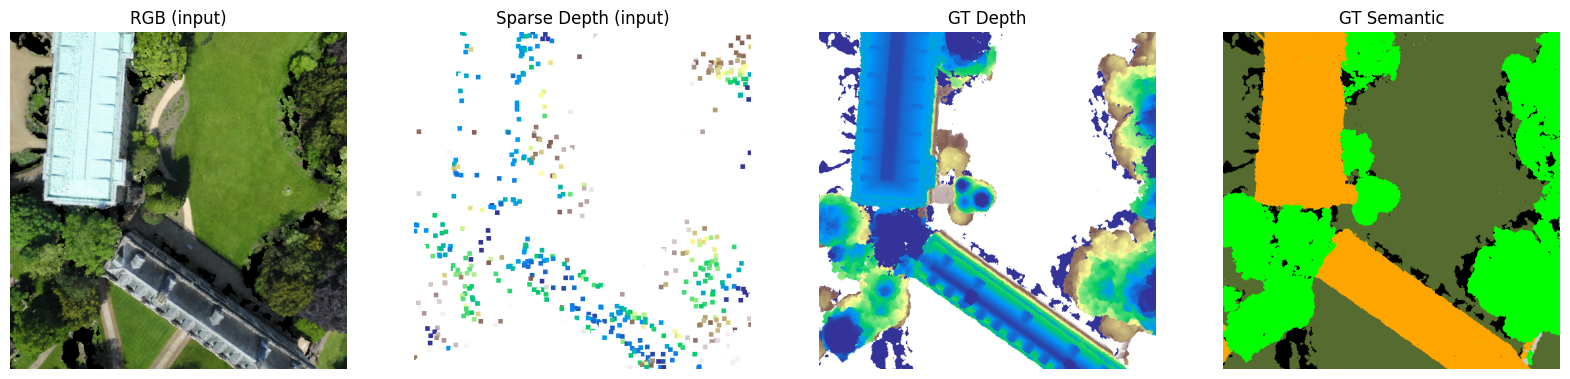

In [46]:
%matplotlib inline
from imageio import imread
import numpy as np
import matplotlib.pyplot as plt
from utils.semantic_labels import convert_class_to_rgb_sensat_simplified 
from vis.vis import pseudo_color_map, pseudo_color_map_sparse

rgb_file = f"{PATH}/RGB.png" 
sparse_depth_file = f"{PATH}/SparseDepth.png"
gt_depth_file = f"{PATH}/GT_Depth.png"
gt_sem_file = f"{PATH}/GT_Semantics.png"

depth_scale = 100
# depth_min = 40
# depth_max = 90

# calculate depth scale / min and max
gt_depth = imread(gt_depth_file)/depth_scale
depth_min, depth_max = np.percentile(gt_depth[gt_depth > 0], [5, 95])
print(f"Depth min: {depth_min:.2f} m, Depth max: {depth_max:.2f} m")

# Visualize the input data and the groundtruth
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(20,5))
rgb = imread(rgb_file) 
ax1.imshow(rgb)
ax1.set_title('RGB (input)')
ax1.axis('off')
sparsedepth = imread(sparse_depth_file)/depth_scale 
sparsedepth_vis = pseudo_color_map_sparse(sparsedepth,depth_min,depth_max)
ax2.imshow(sparsedepth_vis)
ax2.set_title('Sparse Depth (input)')
ax2.axis('off')
gt_depth = imread(gt_depth_file)/depth_scale
gt_depth_vis = pseudo_color_map(gt_depth,depth_min,depth_max)
ax3.imshow(gt_depth_vis)
ax3.set_title('GT Depth')
ax3.axis('off')
gt_sem = imread(gt_sem_file)
gt_sem_vis = convert_class_to_rgb_sensat_simplified(gt_sem)
ax4.imshow(gt_sem_vis)
ax4.set_title('GT Semantic')
ax4.axis('off')
plt.show()

In [47]:
from imageio import imread
import numpy as np

gt = imread(gt_depth_file)
sp = imread(sparse_depth_file)

print("GT dtype/min/max:", gt.dtype, gt.min(), gt.max())
print("SP dtype/min/max:", sp.dtype, sp.min(), sp.max())

print("GT nonzero:", np.count_nonzero(gt))
print("SP nonzero:", np.count_nonzero(sp))

gt_m = gt / depth_scale
sp_m = sp / depth_scale

mask = sp > 0
print("Sparse points:", mask.sum())

if mask.sum() > 0:
    print("Sparse depth range in meters:", sp_m[mask].min(), sp_m[mask].max())
    print("GT depth at sparse points:", gt_m[mask].min(), gt_m[mask].max())

GT dtype/min/max: uint16 0 7539
SP dtype/min/max: uint16 0 8736
GT nonzero: 248823
SP nonzero: 1000
Sparse points: 1000
Sparse depth range in meters: 55.94 87.36
GT depth at sparse points: 55.73 75.33


/tmp/ipykernel_4489/2546712914.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  gt = imread(gt_depth_file)
/tmp/ipykernel_4489/2546712914.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  sp = imread(sparse_depth_file)


### Get the 2D segmentation

Using cache found in /home/couldntsat/.cache/torch/hub/pytorch_vision_v0.8.0


/tmp/ipykernel_4489/2586898980.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_model_path, map_location=device)


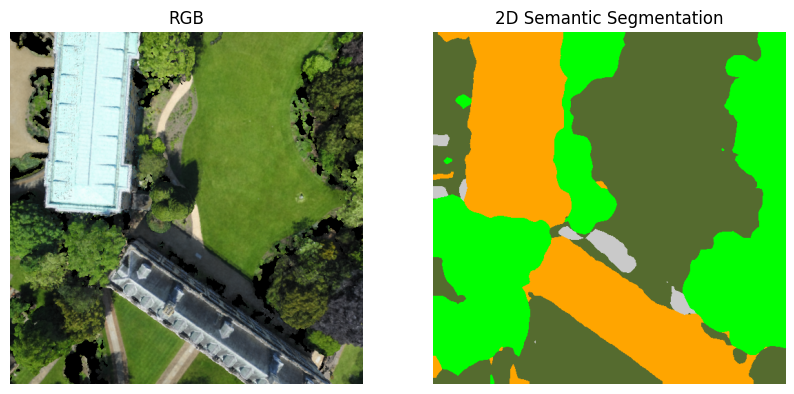

In [48]:
import torch
import torch.nn as nn
from torchvision import transforms
from config import get_sensat_cfg

save_model_path = "checkpoints/deeplab/model_best_semantic.tar"
cfg_file = "Sensat_basic.yaml"

cfg = get_sensat_cfg()
cfg.merge_from_file(cfg_file)

# Load a trained deeplabv3 2D semantic segmentation model
device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')
model_2dseg = torch.hub.load('pytorch/vision:v0.8.0', 'deeplabv3_resnet50', pretrained=True)
model_2dseg.classifier[4] = nn.Conv2d(256, cfg.MODEL.DEEPLAB.NUM_CLASSES, kernel_size=1, stride=1)
model_2dseg.to(device)
checkpoint = torch.load(save_model_path, map_location=device)
model_2dseg.load_state_dict(checkpoint["model_state_dict"])
model_2dseg.eval()

# The input is an RGB image
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(rgb)
input_img = input_tensor.unsqueeze(0).to(device)
pred_semantic_features = model_2dseg(input_img)["out"]
pred_semantic = pred_semantic_features.detach().max(dim=1)[1].cpu().numpy()[0,::]
pred_semantic_vis = convert_class_to_rgb_sensat_simplified(pred_semantic)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.imshow(rgb)
ax1.set_title('RGB')
ax1.axis('off')
ax2.imshow(pred_semantic_vis)
ax2.set_title('2D Semantic Segmentation')
ax2.axis('off')
plt.show()

## Mesh initialization using sparse depth measurements

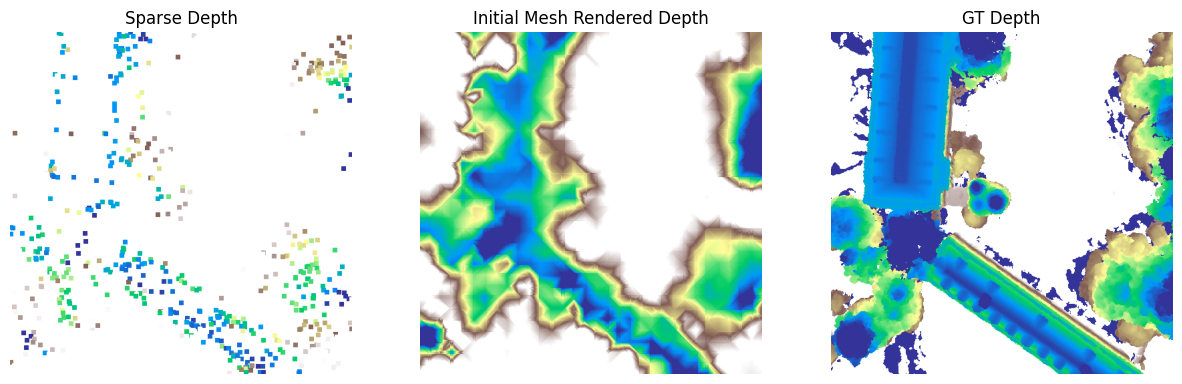

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(1.1391963…

In [49]:
import meshplot as mp
import numpy as np 
from mesh_init.mesh_init_linear_solver import init_mesh_sparse
from mesh_init.mesh_renderer import mesh_render_depth
from pytorch3d.structures import Meshes
from vis.vis import texture_mesh_vertices

num_mesh_vertices = 1024
image_size = 512
focal_length = -2
# depth_min = 40
# depth_max = 90

# Initialize the mesh using only the sparse depth
init_mesh_vertices, init_mesh_faces = init_mesh_sparse(sparsedepth,num_mesh_vertices,w_laplacian=0.5, device=device)
init_mesh_vertices_tensor = torch.tensor(init_mesh_vertices,dtype=torch.float32,device=device)
init_mesh_faces_tensor = torch.tensor(init_mesh_faces,dtype=torch.int64,device=device)
init_mesh = Meshes(verts=[init_mesh_vertices_tensor], faces=[init_mesh_faces_tensor])

init_mesh_depth = mesh_render_depth(init_mesh,image_size=image_size,focal_length=focal_length, device=device)
init_mesh_depth_vis = pseudo_color_map(init_mesh_depth,depth_min,depth_max)

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(15,5))
ax1.imshow(sparsedepth_vis)
ax1.set_title('Sparse Depth')
ax1.axis('off')
ax2.imshow(init_mesh_depth_vis)
ax2.set_title('Initial Mesh Rendered Depth')
ax2.axis('off')
ax3.imshow(gt_depth_vis)
ax3.set_title('GT Depth')
ax3.axis('off')
plt.show()

init_mesh_height_color = texture_mesh_vertices(init_mesh_vertices, depth_min, depth_max)
rotate_matrix = np.array([[1,0,0],[0,-np.sqrt(3)/2,1/2],[0,-1/2,-np.sqrt(3)/2]])
mp.plot(init_mesh_vertices@rotate_matrix, init_mesh_faces, init_mesh_height_color)

## Mesh refinement

In [50]:
import os
from pytorch3d.structures import Meshes
from scipy import ndimage
from torchvision import transforms
from config import get_sensat_cfg
from model.models import VoxMeshHead

save_model_path = "checkpoints/Sem_Dice/model_best_depth.tar"
depth_scale = 100
device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')

# Load a trained 2D-3D model for mesh refinement
cfg = get_sensat_cfg()
cfg.merge_from_file(os.path.join(save_model_path,"..","Sensat_basic.yaml"))
model = VoxMeshHead(cfg)
checkpoint = torch.load(save_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

# Combine the 2D inputs, including the RGB, the initial mesh rendered depth and the sparse depth EDT.
rgb_tensor = transforms.ToTensor()(rgb).unsqueeze(0).to(device)
init_mesh_depth_tensor = transforms.ToTensor()(init_mesh_depth/depth_scale).unsqueeze(0).to(device)
sparsedepth_mask = (sparsedepth<=0)*1
depth_edt = ndimage.distance_transform_edt(sparsedepth_mask)
depth_edt_tensor = transforms.ToTensor()(depth_edt).unsqueeze(0).to(device)
input_img = torch.cat((rgb_tensor, init_mesh_depth_tensor, depth_edt_tensor), dim=1).to(torch.float)

# Normalized the mesh
init_mesh_scale = torch.mean(init_mesh_vertices_tensor[:,2])
init_mesh_vertices_norm_tensor = init_mesh_vertices_tensor / init_mesh_scale
init_mesh = Meshes(verts=[init_mesh_vertices_norm_tensor], faces=[init_mesh_faces_tensor])

# The model takes in the concatenated 2D inputs, the initial mesh and the 2D semantic segmentation
refine_mesh = model(input_img, init_mesh, pred_semantic_features)
refine_mesh = refine_mesh[1].scale_verts(init_mesh_scale.unsqueeze(0).to(device))

/tmp/ipykernel_4489/3470507561.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_model_path, map_location=device)


Visualize the refined mesh.

1
2
3


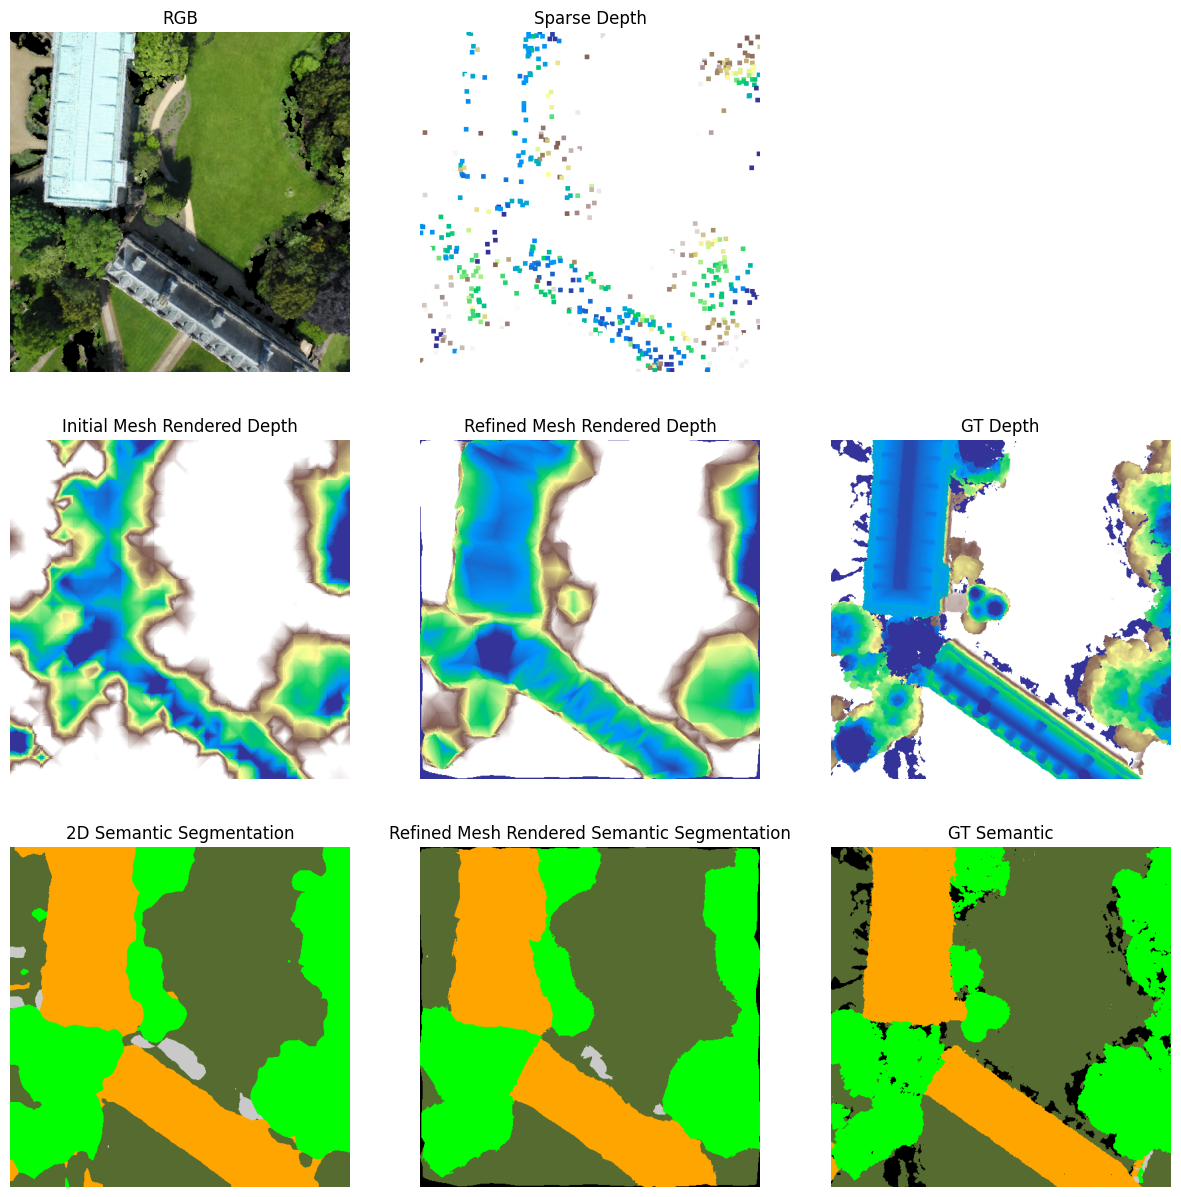

4
5
6
7
8


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.511783…

9


In [51]:
from mesh_init.mesh_renderer import render_mesh_texture
from utils.semantic_labels import convert_class_to_rgb_sensat_simplified 
from vis.vis import pseudo_color_map

device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')
# depth_min = 40
# depth_max = 90
image_size = 512
focal_length = -2

refine_mesh_semantic, refine_mesh_depth = render_mesh_texture(refine_mesh,image_size=image_size,focal_length=focal_length,device=device)
refine_mesh_semantic_vis = convert_class_to_rgb_sensat_simplified(refine_mesh_semantic)
refine_mesh_depth_vis = pseudo_color_map(refine_mesh_depth,depth_min,depth_max)

fig, ((ax11,ax12,ax13),(ax21,ax22,ax23),(ax31,ax32,ax33)) = plt.subplots(3,3,figsize=(15,15))

ax11.imshow(rgb)
ax11.set_title('RGB')
ax11.axis('off')
ax12.imshow(sparsedepth_vis)
ax12.set_title('Sparse Depth')
ax12.axis('off')
ax13.axis('off')
print(1)

ax21.imshow(init_mesh_depth_vis)
ax21.set_title('Initial Mesh Rendered Depth')
ax21.axis('off')
ax22.imshow(refine_mesh_depth_vis)
ax22.set_title('Refined Mesh Rendered Depth')
ax22.axis('off')
ax23.imshow(gt_depth_vis)
ax23.set_title('GT Depth')
ax23.axis('off')
print(2)

ax31.imshow(pred_semantic_vis)
ax31.set_title('2D Semantic Segmentation')
ax31.axis('off')
ax32.imshow(refine_mesh_semantic_vis)
ax32.set_title('Refined Mesh Rendered Semantic Segmentation')
ax32.axis('off')
ax33.imshow(gt_sem_vis)
ax33.set_title('GT Semantic')
ax33.axis('off')
print(3)

plt.show()

refine_mesh_vertices, refine_mesh_faces = refine_mesh.get_mesh_verts_faces(0)
print(4)
refine_mesh_vertices = refine_mesh_vertices.detach().cpu().numpy()
print(5)
refine_mesh_faces = refine_mesh_faces.detach().cpu().numpy()
print(6)
refine_mesh_height_color = texture_mesh_vertices(refine_mesh_vertices, depth_min, depth_max)
print(7)
rotate_matrix = np.array([[1,0,0],[0,-np.sqrt(3)/2,1/2],[0,-1/2,-np.sqrt(3)/2]])
print(8)
mp.plot(refine_mesh_vertices@rotate_matrix, refine_mesh_faces, refine_mesh_height_color)
print(9)

## Save the refined mesh with different textures (Color, Elevation, Semantics)

You can visualize the saved meshes in other apps like [MeshLab](https://www.meshlab.net/) or [Open3D](http://www.open3d.org/).

In [52]:
import os, sys
import numpy as np
import open3d as o3d
from vis.vis import texture_mesh
focal_length_texture = 2

os.makedirs(f"{PATH}/refined_mesh", exist_ok=True)

print("A import open3d ok", flush=True)

verts = np.ascontiguousarray(refine_mesh_vertices, dtype=np.float64)
faces = np.ascontiguousarray(refine_mesh_faces, dtype=np.int32)

print("B verts/faces cast ok", verts.shape, verts.dtype, faces.shape, faces.dtype, flush=True)
print("C finite verts:", np.isfinite(verts).all(), flush=True)
print("D faces min/max:", faces.min(), faces.max(), "nverts:", len(verts), flush=True)

assert np.isfinite(verts).all()
assert faces.ndim == 2 and faces.shape[1] == 3
assert faces.min() >= 0
assert faces.max() < len(verts)

mesh = o3d.geometry.TriangleMesh()
print("E TriangleMesh() ok", flush=True)

mesh.vertices = o3d.utility.Vector3dVector(verts)
print("F vertices assigned", flush=True)

mesh.triangles = o3d.utility.Vector3iVector(faces)
print("G triangles assigned", flush=True)

mesh.compute_vertex_normals()
print("H normals ok", flush=True)

rgb_tex = texture_mesh(rgb, mesh, focal_length_texture)
print("I rgb texture ok", flush=True)

ok = o3d.io.write_triangle_mesh(f"{PATH}/refined_mesh/test_rgb.obj", rgb_tex)
print("J rgb write ok:", ok, flush=True)

A import open3d ok
B verts/faces cast ok (1024, 3) float64 (1922, 3) int32
C finite verts: True
D faces min/max: 0 1023 nverts: 1024
E TriangleMesh() ok
F vertices assigned
G triangles assigned
H normals ok
I rgb texture ok
[Open3D WARNING] Write OBJ can not include triangle normals.
J rgb write ok: True


In [53]:
depth_tex = texture_mesh(refine_mesh_depth_vis, mesh, focal_length_texture)
print("K depth texture ok", flush=True)
ok = o3d.io.write_triangle_mesh(f"{PATH}/refined_mesh/test_depth.obj", depth_tex)
print("L depth write ok:", ok, flush=True)

sem_tex = texture_mesh(refine_mesh_semantic_vis, mesh, focal_length_texture)
print("M semantic texture ok", flush=True)
ok = o3d.io.write_triangle_mesh(f"{PATH}/refined_mesh/test_sem.obj", sem_tex)
print("N semantic write ok:", ok, flush=True)

K depth texture ok
[Open3D WARNING] Write OBJ can not include triangle normals.
L depth write ok: True
M semantic texture ok
[Open3D WARNING] Write OBJ can not include triangle normals.
N semantic write ok: True


In [54]:
print("bad verts:", np.isnan(verts).sum(), np.isinf(verts).sum())
print("bad faces <0:", (faces < 0).sum())
print("bad faces >= nverts:", (faces >= len(verts)).sum())

bad verts: 0 0
bad faces <0: 0
bad faces >= nverts: 0


In [55]:
# import open3d as o3d
# from vis.vis import texture_mesh

# focal_length_texture = 2
# refine_mesh_rgb_path = f"{PATH}/refined_mesh/refine_rgb.obj"
# refine_mesh_depth_path = f"{PATH}/refined_mesh/refine_depth.obj"
# refine_mesh_semantic_path = f"{PATH}/refined_mesh/refine_semantic.obj"

# # Save the mesh in the Open3D TriangleMesh
# refine_mesh_o3d = o3d.geometry.TriangleMesh()
# refine_mesh_o3d.vertices = o3d.utility.Vector3dVector(refine_mesh_vertices)
# refine_mesh_o3d.triangles = o3d.utility.Vector3iVector(refine_mesh_faces)
    
# # RGB colors
# refine_mesh_rgb = texture_mesh(rgb, refine_mesh_o3d, focal_length_texture)
# o3d.io.write_triangle_mesh(refine_mesh_rgb_path,refine_mesh_rgb)

# # Elevation/Depth
# refine_mesh_depth = texture_mesh(refine_mesh_depth_vis, refine_mesh_o3d, focal_length_texture)
# o3d.io.write_triangle_mesh(refine_mesh_depth_path,refine_mesh_depth)

# # Semantic
# refine_mesh_semantic = texture_mesh(refine_mesh_semantic_vis, refine_mesh_o3d, focal_length_texture)
# o3d.io.write_triangle_mesh(refine_mesh_semantic_path,refine_mesh_semantic)
